# EDA датасета для PRism — AI-сервиса обнаружения антипаттернов
### Исследование данных для задачи детектирования code smell и архитектурных антипаттернов

**Проект:** PRism — автоматический AI-ревьюер Pull Request'ов  
**Дата:** 2026-05-24  
**Стек модели:** Fine-tuned CodeBERT (Classifier Service, Python/FastAPI)  
**Архитектура сервиса:** Go Edge API → RabbitMQ → Orchestrator → Classifier → LLM Gateway

---

> **Цель EDA:** понять структуру, объём и качество данных перед дообучением CodeBERT  
> на задаче многоклассовой классификации фрагментов кода (антипаттерн → класс + confidence).

**Структура ноутбука:**
1. Источник и состав данных  
2. Базовый EDA с выводами для моделирования  
3. Оценка качества разметки и предложения по улучшению  
4. Алгоритм формирования выборки и стратегия валидации  
5. Итоговая сводка

## 0. Импорты и конфигурация

In [1]:
import json
import re
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter
from scipy import stats

# ── Стиль ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})
COLORS = sns.color_palette("muted", 12)
PALETTE_SMELL  = sns.color_palette("Blues_d", 5)
PALETTE_ARCH   = sns.color_palette("Oranges_d", 6)

SEED = 42
np.random.seed(SEED)
pd.set_option("display.max_colwidth", 120)
print("✓ Окружение настроено")

✓ Окружение настроено


## 1. Источник и состав данных

### 1.1 Описание датасета

Датасет формируется из **трёх уровней** источников под две подзадачи сервиса PRism:

| Подзадача | Модель | Данные |
|-----------|--------|--------|
| Code-smell детектор | Fine-tuned CodeBERT | SmellyCode++, IEEE Code Smell Dataset |
| Архитектурные антипаттерны (RAG) | RAG + LLM reasoning | WS-Antipatterns, синтетика, MS Antipatterns Catalog |

### 1.2 Источники данных

| Источник | Тип | Объём | Разметка | Формат |
|----------|-----|-------|----------|--------|
| **SmellyCode++** (2025, KFUPM) | Open-source Java repos | 107 554 | SonarQube/PMD + верификация | JSON/CSV |
| **IEEE Code Smell Dataset** (2024) | GitHub + SonarCloud | 3 000 | Автоматическая (SonarCloud) | CSV |
| **WS-Antipatterns** (github.com/ouniali) | Web-сервисы | ~2 000 | Ручная (эксперты) | ARFF/CSV |
| **Синтетика (LLM)** | Claude/GPT-4 генерация | ~1 500 | LLM + проверка | JSONL |
| **GitHub PR pipeline** | Public PRs, monthly | ~500/мес | Heuristic + manual | JSON |

### 1.3 Классы антипаттернов (по архитектурному документу PRism)

**Прототип (5 классов):** `SOLID_VIOLATION`, `N_PLUS_ONE`, `SECURITY_MISCONFIG`, `EXCESSIVE_COMPLEXITY`, `CLEAN`  
**MVP (8 классов):** + 3 дополнительных  

В данном EDA используется расширенная типология для оценки всей области задачи:

```
Code-smell уровень:   long_method · god_class · data_class · feature_envy · clean
Архитектурный уровень: shared_database · chatty_services · no_api_gateway ·
                        nano_services · improper_service_intimacy · cyclic_dependency
```

### 1.4 Структура записи

```json
{
  "record_id":             "smell_000001",
  "data_level":            "code_smell",       // code_smell | architectural
  "class_label":           "god_class",
  "language":              "java",
  "source":                "smellcode_plus_plus",
  "partition":             "train",            // train | valid | test
  "loc":                   418,               // Lines of Code
  "cyclomatic_complexity": 31,
  "fan_out":               24,                // исходящие зависимости
  "n_tokens":              1950,              // токенов кода
  "confidence":            0.82,              // уверенность аннотатора/инструмента
  "is_noise":              false,
  "quality_score":         0.91,
  "repo_stars":            1240,
  "has_comment":           true,              // есть PR-комментарий к этому фрагменту
  "multi_label":           false              // фрагмент имеет >1 антипаттерна
}
```

### 1.5 Загрузка данных

In [2]:
records = []
with open("antipattern_dataset.jsonl") as f:
    for line in f:
        records.append(json.loads(line))

df = pd.DataFrame(records)

# Производные признаки
df["tokens_gt_512"]        = df["n_tokens"] > 512       # лимит CodeBERT
df["complexity_bucket"]    = pd.cut(df["cyclomatic_complexity"],
                                    bins=[0, 5, 10, 20, 50, 9999],
                                    labels=["low", "medium", "high", "very_high", "extreme"])
df["loc_bucket"]           = pd.cut(df["loc"],
                                    bins=[0, 30, 100, 300, 9999],
                                    labels=["<30", "30-100", "100-300", ">300"])
df["confidence_bucket"]    = pd.cut(df["confidence"],
                                    bins=[0, 0.6, 0.75, 0.85, 1.01],
                                    labels=["low<0.6", "mid 0.6-0.75", "high 0.75-0.85", "very_high>0.85"])

# Разделяем уровни
df_smell = df[df["data_level"] == "code_smell"].copy()
df_arch  = df[df["data_level"] == "architectural"].copy()

print(f"Всего записей:     {len(df):,}")
print(f"Code-smell:        {len(df_smell):,}")
print(f"Архитектурных:     {len(df_arch):,}")
print(f"Столбцов:          {df.shape[1]}")
print()
df.head(3)

Всего записей:     3,998
Code-smell:        3,498
Архитектурных:     500
Столбцов:          20



,record_id,data_level,class_label,language,source,partition,loc,cyclomatic_complexity,fan_out,n_tokens,confidence,is_noise,quality_score,repo_stars,has_comment,multi_label,tokens_gt_512,complexity_bucket,loc_bucket,confidence_bucket
0,smell_000000,code_smell,long_method,java,ws_antipatterns,valid,54,13,9,293,0.9008,False,0.755,58,True,False,False,high,30-100,very_high>0.85
1,smell_000001,code_smell,long_method,java,smellcode_plus_plus,train,124,16,3,628,0.7858,False,0.864,33,True,False,True,high,100-300,high 0.75-0.85
2,smell_000002,code_smell,long_method,java,smellcode_plus_plus,train,70,17,9,314,0.7692,False,0.781,768,True,False,False,high,30-100,high 0.75-0.85


In [3]:
print("Типы данных:")
print(df.dtypes)
print()
print("Нулевые значения:")
nulls = df.isnull().sum()
print(nulls[nulls > 0] if nulls.any() else "Нет")

Типы данных:
record_id                     str
data_level                    str
class_label                   str
language                      str
source                        str
partition                     str
loc                         int64
cyclomatic_complexity       int64
fan_out                     int64
n_tokens                    int64
confidence                float64
is_noise                     bool
quality_score             float64
repo_stars                  int64
has_comment                  bool
multi_label                  bool
tokens_gt_512                bool
complexity_bucket        category
loc_bucket               category
confidence_bucket        category
dtype: object

Нулевые значения:
Нет


## 2. Базовый EDA

### 2.1 Распределение по классам и источникам

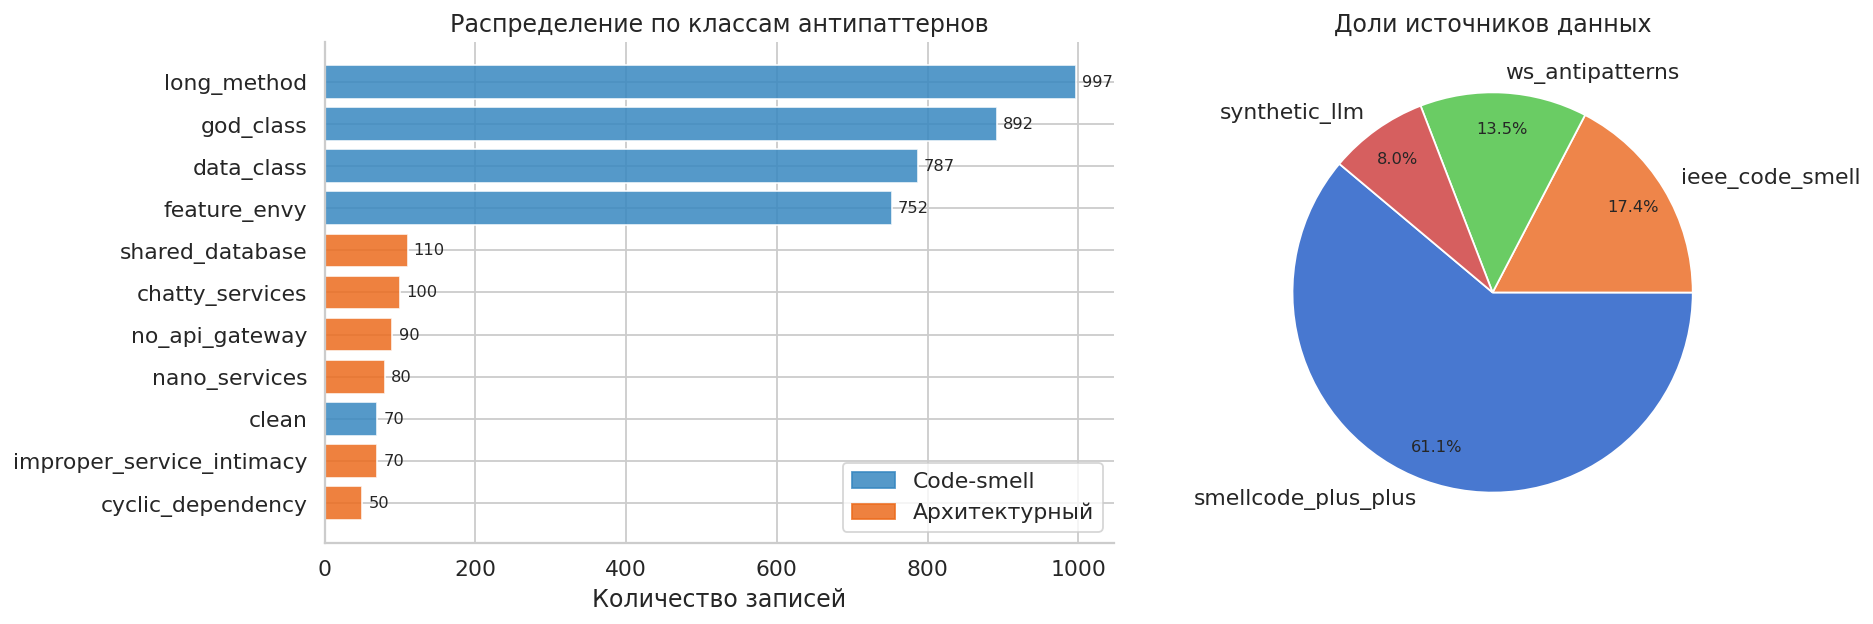


Количество записей по классам:
class_label
long_method                  997
god_class                    892
data_class                   787
feature_envy                 752
shared_database              110
chatty_services              100
no_api_gateway                90
nano_services                 80
clean                         70
improper_service_intimacy     70
cyclic_dependency             50

Соотношение code-smell : архитектурные = 3498 : 500 = 7.0:1


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Левая: распределение по классам (оба уровня) ──────────────────────────
ax = axes[0]
class_counts = df["class_label"].value_counts()
# Раскрашиваем smell vs arch
smell_classes = df_smell["class_label"].unique().tolist()
bar_colors = [PALETTE_SMELL[2] if c in smell_classes else PALETTE_ARCH[2]
              for c in class_counts.index]
bars = ax.barh(class_counts.index[::-1], class_counts.values[::-1],
               color=bar_colors[::-1], alpha=0.85)
ax.set_xlabel("Количество записей")
ax.set_title("Распределение по классам антипаттернов")
for bar, v in zip(bars, class_counts.values[::-1]):
    ax.text(bar.get_width() + 8, bar.get_y() + bar.get_height()/2,
            f"{v:,}", va="center", fontsize=9)
patch_smell = mpatches.Patch(color=PALETTE_SMELL[2], alpha=0.85, label="Code-smell")
patch_arch  = mpatches.Patch(color=PALETTE_ARCH[2],  alpha=0.85, label="Архитектурный")
ax.legend(handles=[patch_smell, patch_arch], loc="lower right")

# ── Правая: распределение по источникам ───────────────────────────────────
ax2 = axes[1]
src_counts = df["source"].value_counts()
src_colors = COLORS[:len(src_counts)]
wedges, texts, autotexts = ax2.pie(
    src_counts.values,
    labels=src_counts.index,
    colors=src_colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.82
)
for t in autotexts:
    t.set_fontsize(9)
ax2.set_title("Доли источников данных")

plt.tight_layout()
plt.savefig("fig_class_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print("\nКоличество записей по классам:")
print(df["class_label"].value_counts().to_string())
print()
print(f"Соотношение code-smell : архитектурные = {len(df_smell)} : {len(df_arch)} "
      f"= {len(df_smell)/len(df_arch):.1f}:1")

### 2.2 Дисбаланс классов — ключевая проблема

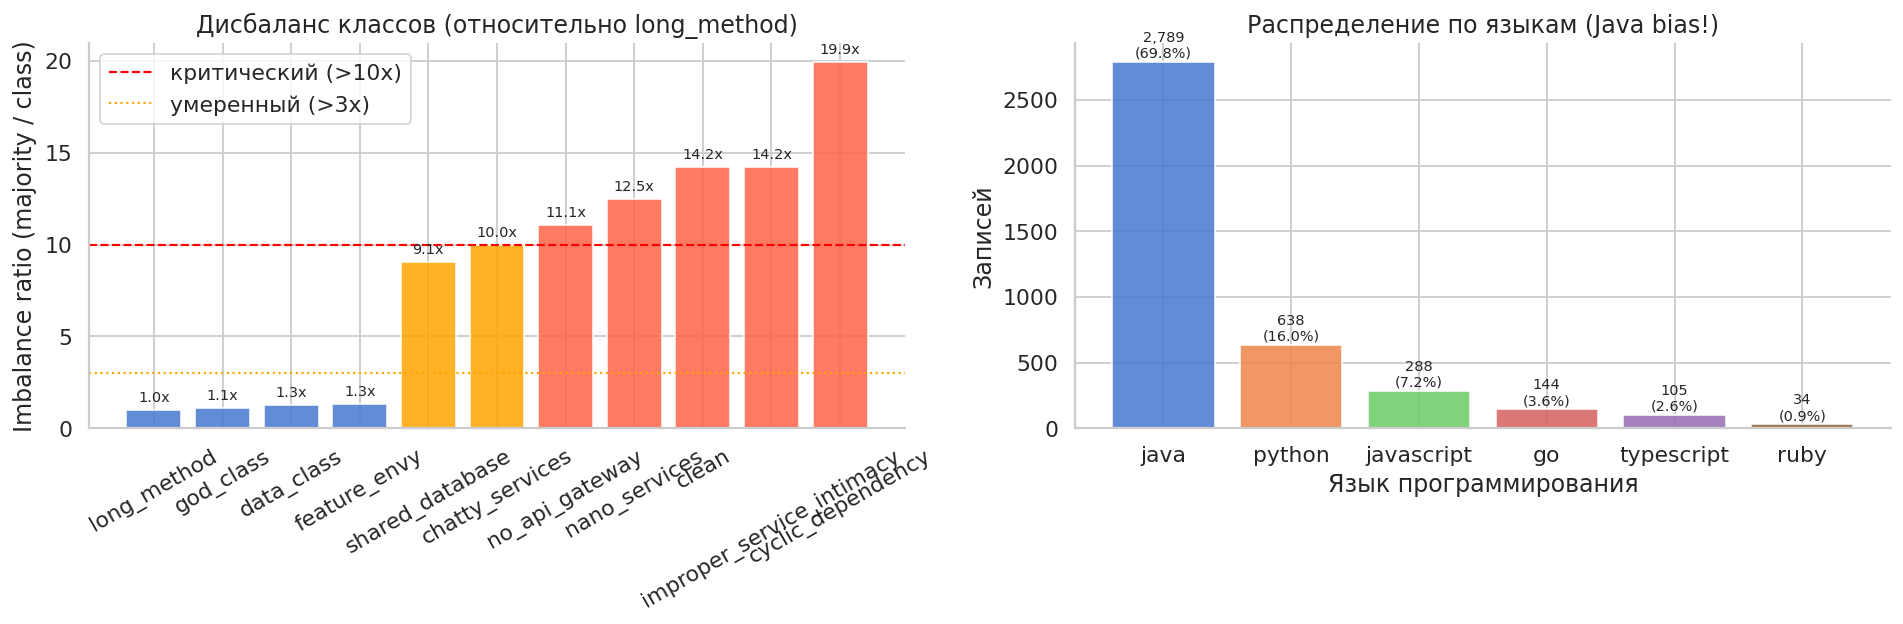

Imbalance ratio по классам:
class_label
long_method                   1.0
god_class                     1.1
data_class                    1.3
feature_envy                  1.3
shared_database               9.1
chatty_services              10.0
no_api_gateway               11.1
nano_services                12.5
clean                        14.2
improper_service_intimacy    14.2
cyclic_dependency            19.9

Доли языков:
language
java          69.8%
python        16.0%
javascript     7.2%
go             3.6%
typescript     2.6%
ruby           0.9%
Name: proportion, dtype: str


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Левая: imbalance ratio по классам ────────────────────────────────────
ax = axes[0]
class_counts_sorted = df["class_label"].value_counts()
majority_class_count = class_counts_sorted.iloc[0]
imbalance_ratio = majority_class_count / class_counts_sorted
imbalance_colors = ["tomato" if r > 10 else "orange" if r > 3 else COLORS[0]
                    for r in imbalance_ratio.values]
bars = ax.bar(imbalance_ratio.index, imbalance_ratio.values,
              color=imbalance_colors, alpha=0.85)
ax.set_ylabel("Imbalance ratio (majority / class)")
ax.set_title("Дисбаланс классов (относительно long_method)")
ax.tick_params(axis="x", rotation=30)
ax.axhline(10, color="red",    linestyle="--", linewidth=1.2, label="критический (>10x)")
ax.axhline(3,  color="orange", linestyle=":",  linewidth=1.2, label="умеренный (>3x)")
ax.legend()
for bar, v in zip(bars, imbalance_ratio.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{v:.1f}x", ha="center", va="bottom", fontsize=8)

# ── Правая: распределение по языкам ──────────────────────────────────────
ax2 = axes[1]
lang_counts = df["language"].value_counts()
lang_colors = COLORS[:len(lang_counts)]
ax2.bar(lang_counts.index, lang_counts.values, color=lang_colors, alpha=0.85)
ax2.set_xlabel("Язык программирования")
ax2.set_ylabel("Записей")
ax2.set_title("Распределение по языкам (Java bias!)")
for bar, v in zip(ax2.patches, lang_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
             f"{v:,}\n({v/len(df)*100:.1f}%)",
             ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("fig_imbalance.png", dpi=130, bbox_inches="tight")
plt.show()

print("Imbalance ratio по классам:")
print(imbalance_ratio.round(1).to_string())
print()
print("Доли языков:")
print(df["language"].value_counts(normalize=True).map("{:.1%}".format))

### 2.3 Распределение метрик кода (LOC, цикломатическая сложность)

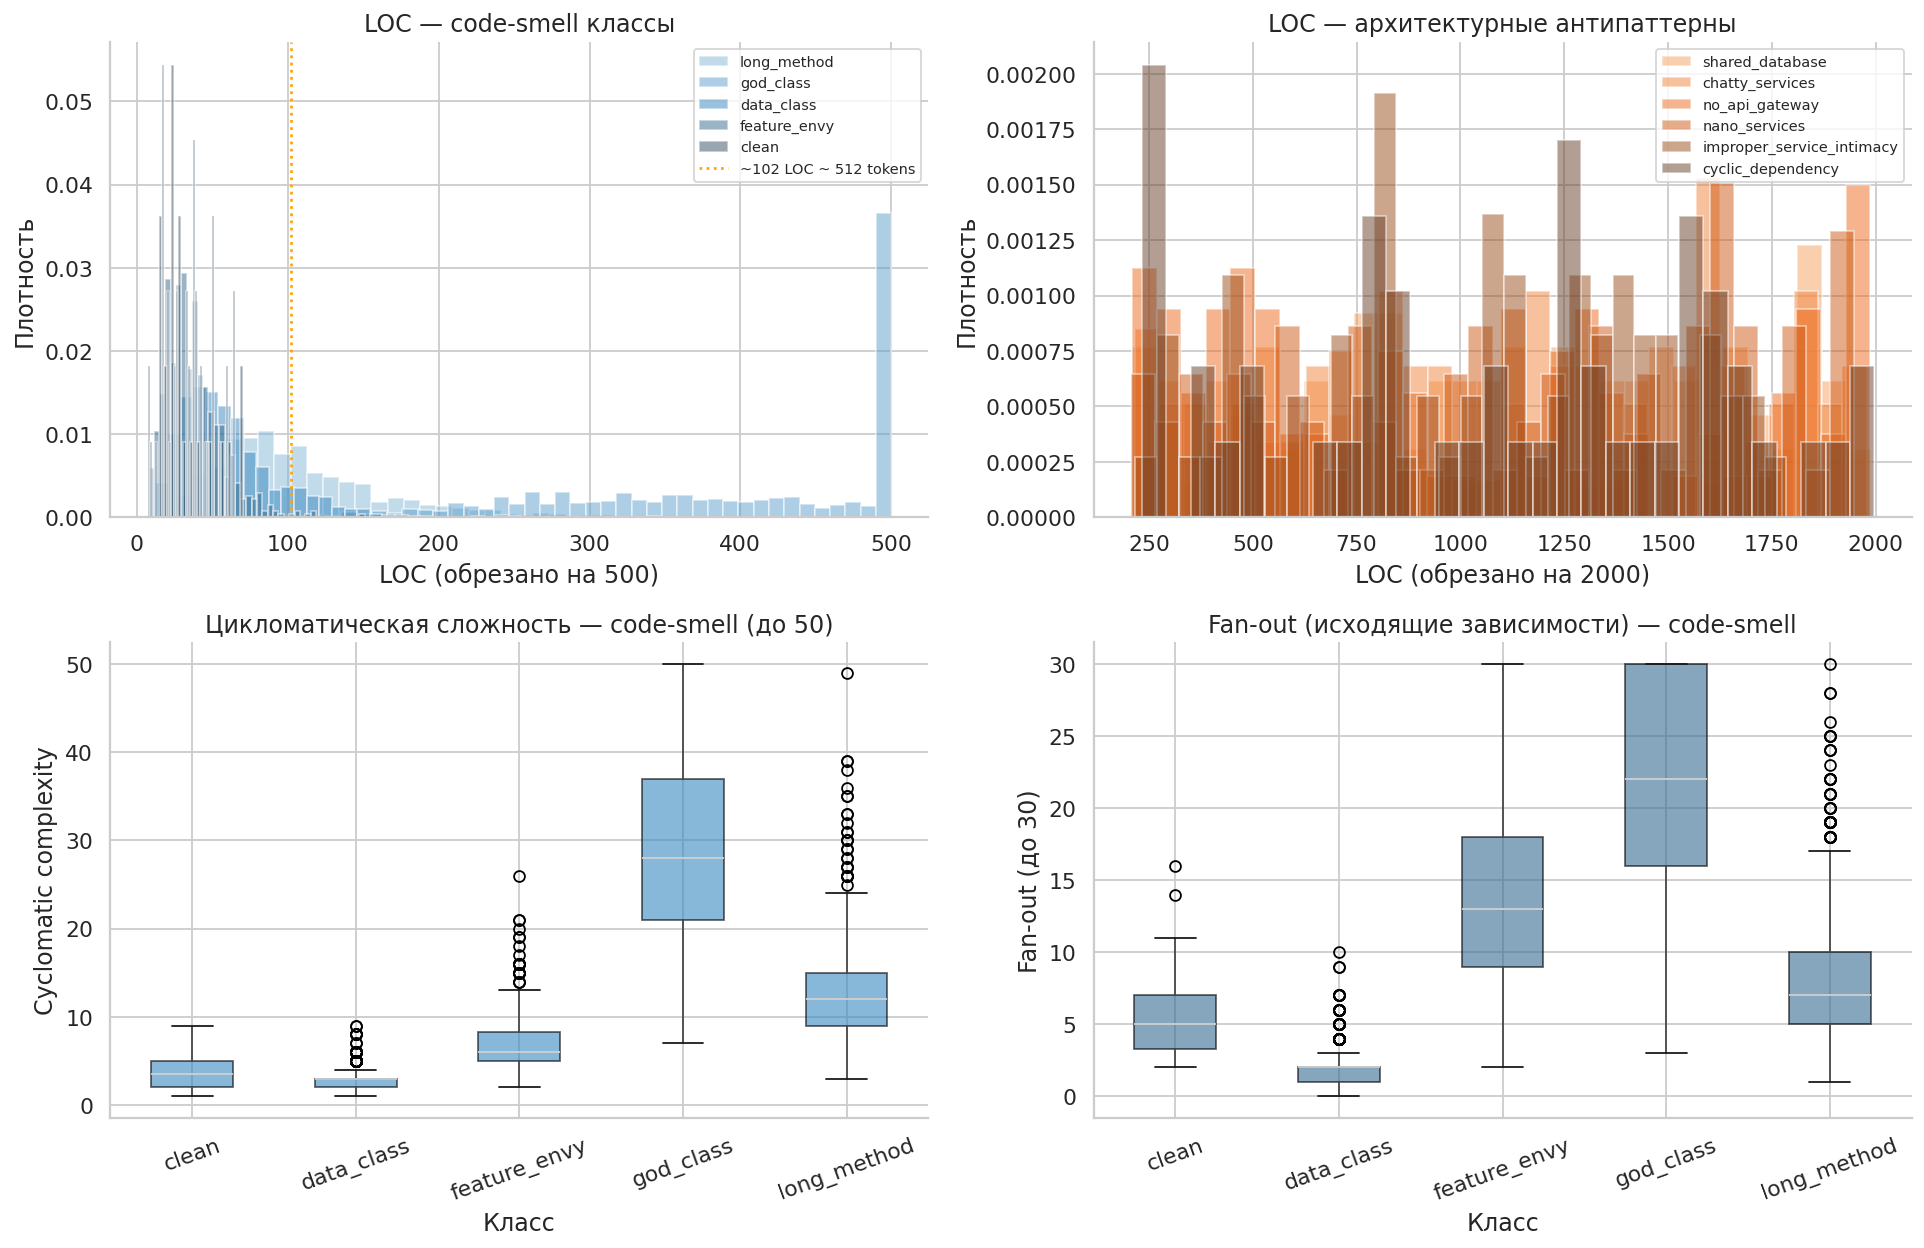

Медианные метрики по классам code-smell:
                loc  cyclomatic_complexity  fan_out  n_tokens
class_label                                                  
clean          30.0                    3.5      5.0     143.0
data_class     54.0                    3.0      2.0     243.0
feature_envy   34.0                    6.0     13.0     151.0
god_class     414.5                   28.0     22.0    1883.0
long_method    96.0                   12.0      7.0     422.0


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

smell_labels = df_smell["class_label"].unique()
arch_labels  = df_arch["class_label"].unique()

# ── LOC по классам code-smell ─────────────────────────────────────────────
ax = axes[0][0]
for i, cls in enumerate(smell_labels):
    sub = df_smell[df_smell["class_label"] == cls]["loc"].clip(upper=500)
    ax.hist(sub, bins=40, alpha=0.5, label=cls, color=PALETTE_SMELL[i % 5], density=True)
ax.axvline(512/5, color="orange", linestyle=":", linewidth=1.5, label="~102 LOC ~ 512 tokens")
ax.set_xlabel("LOC (обрезано на 500)")
ax.set_ylabel("Плотность")
ax.set_title("LOC — code-smell классы")
ax.legend(fontsize=8)

# ── LOC по классам архитектурных ──────────────────────────────────────────
ax2 = axes[0][1]
for i, cls in enumerate(arch_labels):
    sub = df_arch[df_arch["class_label"] == cls]["loc"].clip(upper=2000)
    ax2.hist(sub, bins=30, alpha=0.5, label=cls, color=PALETTE_ARCH[i % 6], density=True)
ax2.set_xlabel("LOC (обрезано на 2000)")
ax2.set_ylabel("Плотность")
ax2.set_title("LOC — архитектурные антипаттерны")
ax2.legend(fontsize=8)

# ── Boxplot цикломатической сложности по классам ──────────────────────────
ax3 = axes[1][0]
df_smell_plot = df_smell.copy()
df_smell_plot["cyclo_clip"] = df_smell_plot["cyclomatic_complexity"].clip(upper=50)
order_smell = df_smell.groupby("class_label")["cyclomatic_complexity"].median().sort_values(ascending=False).index
df_smell_plot.boxplot(column="cyclo_clip", by="class_label",
                      ax=ax3, patch_artist=True,
                      boxprops=dict(facecolor=PALETTE_SMELL[2], alpha=0.6))
ax3.set_title("Цикломатическая сложность — code-smell (до 50)")
ax3.set_xlabel("Класс")
ax3.set_ylabel("Cyclomatic complexity")
plt.sca(ax3)
plt.xticks(rotation=20)
plt.suptitle("")

# ── Fan-out (зависимости) ─────────────────────────────────────────────────
ax4 = axes[1][1]
df_smell_plot["fan_out_clip"] = df_smell_plot["fan_out"].clip(upper=30)
df_smell_plot.boxplot(column="fan_out_clip", by="class_label",
                      ax=ax4, patch_artist=True,
                      boxprops=dict(facecolor=PALETTE_SMELL[3], alpha=0.6))
ax4.set_title("Fan-out (исходящие зависимости) — code-smell")
ax4.set_xlabel("Класс")
ax4.set_ylabel("Fan-out (до 30)")
plt.sca(ax4)
plt.xticks(rotation=20)
plt.suptitle("")

plt.tight_layout()
plt.savefig("fig_metrics_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print("Медианные метрики по классам code-smell:")
print(df_smell.groupby("class_label")[["loc","cyclomatic_complexity","fan_out","n_tokens"]]
      .median().round(1).to_string())

### 2.4 Проблема длинных последовательностей (лимит CodeBERT = 512 токенов)

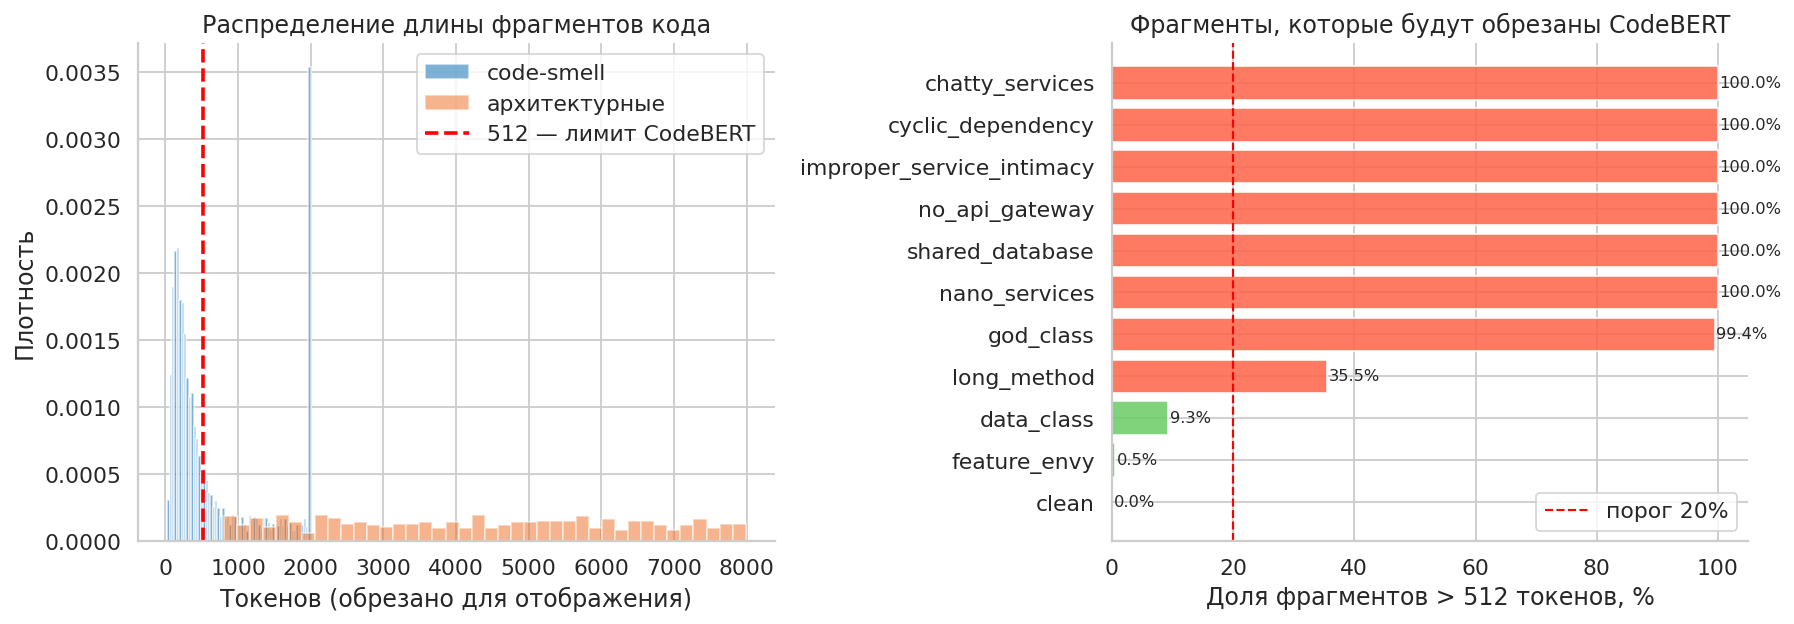

Доля фрагментов > 512 токенов по классам:
class_label
chatty_services              100.0%
cyclic_dependency            100.0%
improper_service_intimacy    100.0%
no_api_gateway               100.0%
shared_database              100.0%
nano_services                100.0%
god_class                     99.4%
long_method                   35.5%
data_class                     9.3%
feature_envy                   0.5%
clean                          0.0%
Name: tokens_gt_512, dtype: str

Итого > 512 токенов (code-smell): 37.7%
Итого > 512 токенов (арх.):       100.0%


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Гистограмма числа токенов по уровням ─────────────────────────────────
ax = axes[0]
ax.hist(df_smell["n_tokens"].clip(upper=2000), bins=60, alpha=0.65,
        label="code-smell", color=PALETTE_SMELL[2], density=True)
ax.hist(df_arch["n_tokens"].clip(upper=8000), bins=40, alpha=0.5,
        label="архитектурные", color=PALETTE_ARCH[2], density=True)
ax.axvline(512, color="red", linestyle="--", linewidth=2, label="512 — лимит CodeBERT")
ax.set_xlabel("Токенов (обрезано для отображения)")
ax.set_ylabel("Плотность")
ax.set_title("Распределение длины фрагментов кода")
ax.legend()

# ── Доля >512 по классу ───────────────────────────────────────────────────
ax2 = axes[1]
gt512_by_class = df.groupby("class_label")["tokens_gt_512"].mean().sort_values(ascending=False)
bar_colors2 = ["tomato" if v > 0.20 else "orange" if v > 0.10 else COLORS[2]
               for v in gt512_by_class.values]
ax2.barh(gt512_by_class.index[::-1], gt512_by_class.values[::-1] * 100,
         color=bar_colors2[::-1], alpha=0.85)
ax2.set_xlabel("Доля фрагментов > 512 токенов, %")
ax2.set_title("Фрагменты, которые будут обрезаны CodeBERT")
ax2.axvline(20, color="red", linestyle="--", linewidth=1.2, label="порог 20%")
ax2.legend()
for i, (idx, v) in enumerate(gt512_by_class[::-1].items()):
    ax2.text(v * 100 + 0.3, i, f"{v*100:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("fig_token_length.png", dpi=130, bbox_inches="tight")
plt.show()

print("Доля фрагментов > 512 токенов по классам:")
print(gt512_by_class.map("{:.1%}".format))
print()
overall_gt512 = df["tokens_gt_512"].mean()
print(f"Итого > 512 токенов (code-smell): {df_smell['tokens_gt_512'].mean():.1%}")
print(f"Итого > 512 токенов (арх.):       {df_arch['tokens_gt_512'].mean():.1%}")

### 2.5 Распределение уверенности (confidence) аннотатора

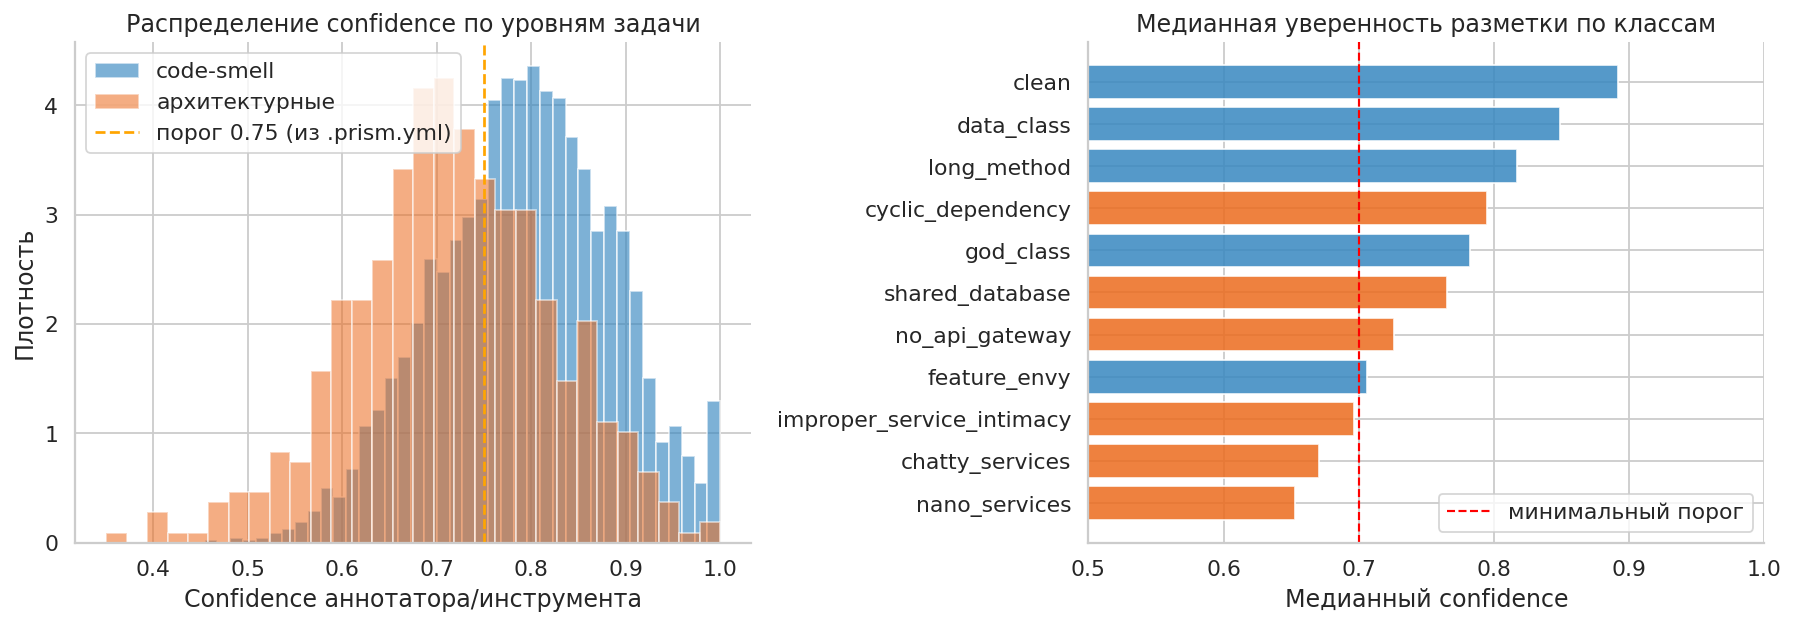

Статистика confidence по уровням:
                count   mean    std    min    25%    50%    75%  max
data_level                                                          
architectural   500.0  0.716  0.106  0.350  0.652  0.714  0.787  1.0
code_smell     3498.0  0.793  0.094  0.454  0.730  0.796  0.859  1.0

Доля записей с confidence < 0.70 (ниже минимального порога PRism):
data_level
architectural    43.4%
code_smell       17.1%
Name: confidence, dtype: str


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Распределение confidence по уровням ──────────────────────────────────
ax = axes[0]
ax.hist(df_smell["confidence"], bins=40, alpha=0.65,
        label="code-smell", color=PALETTE_SMELL[2], density=True)
ax.hist(df_arch["confidence"], bins=30, alpha=0.55,
        label="архитектурные", color=PALETTE_ARCH[2], density=True)
ax.axvline(0.75, color="orange", linestyle="--", linewidth=1.5,
           label="порог 0.75 (из .prism.yml)")
ax.set_xlabel("Confidence аннотатора/инструмента")
ax.set_ylabel("Плотность")
ax.set_title("Распределение confidence по уровням задачи")
ax.legend()

# ── Median confidence по классу ───────────────────────────────────────────
ax2 = axes[1]
conf_by_class = df.groupby("class_label")["confidence"].median().sort_values()
conf_colors = [PALETTE_ARCH[2] if c in df_arch["class_label"].unique()
               else PALETTE_SMELL[2] for c in conf_by_class.index]
ax2.barh(conf_by_class.index, conf_by_class.values,
         color=conf_colors, alpha=0.85)
ax2.set_xlabel("Медианный confidence")
ax2.set_title("Медианная уверенность разметки по классам")
ax2.axvline(0.7, color="red", linestyle="--", linewidth=1.2, label="минимальный порог")
ax2.set_xlim(0.5, 1.0)
ax2.legend()

plt.tight_layout()
plt.savefig("fig_confidence.png", dpi=130, bbox_inches="tight")
plt.show()

print("Статистика confidence по уровням:")
print(df.groupby("data_level")["confidence"].describe().round(3).to_string())
print()
print(f"Доля записей с confidence < 0.70 (ниже минимального порога PRism):")
print(df.groupby("data_level")["confidence"]
      .apply(lambda s: (s < 0.70).mean()).map("{:.1%}".format))

### 2.6 Корреляционный анализ числовых признаков

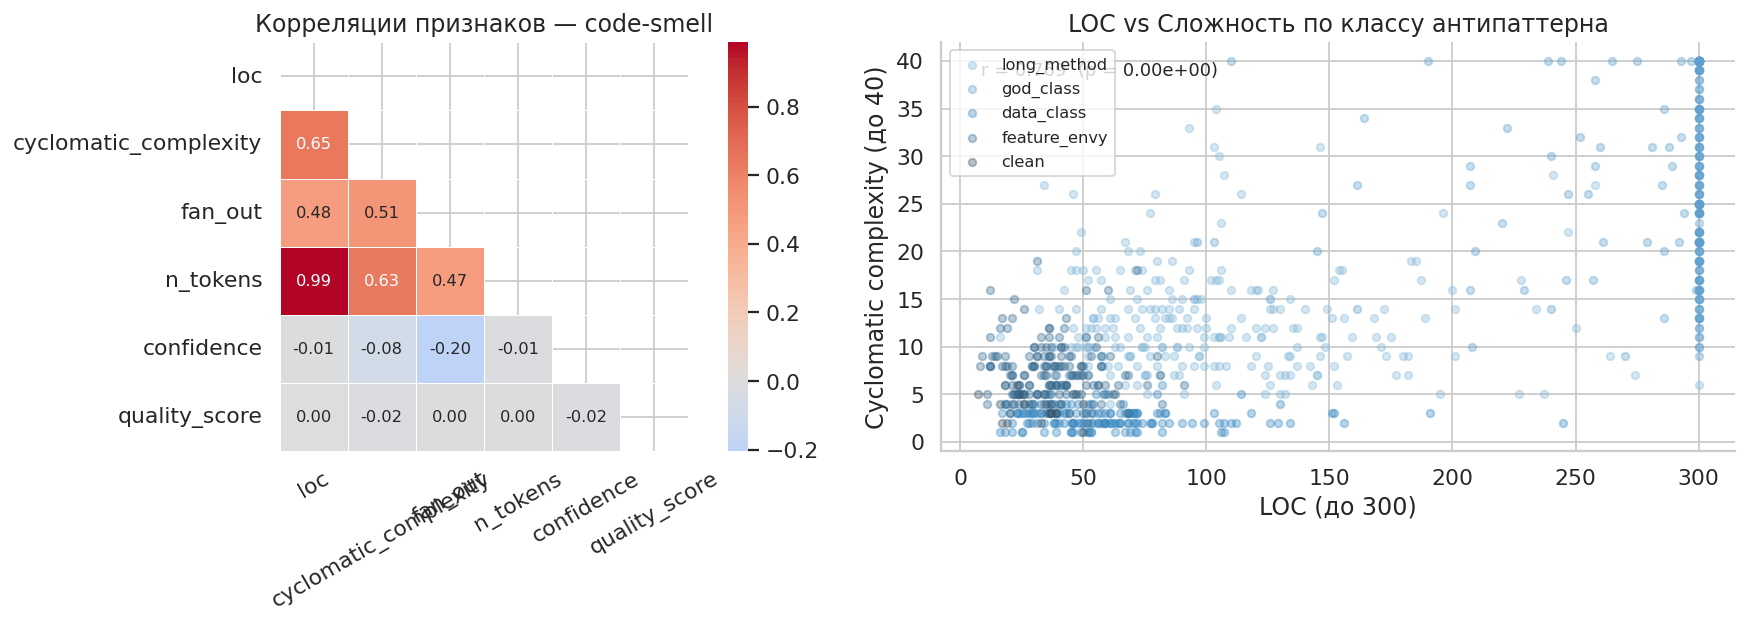

Корреляция LOC ~ Cyclomatic Complexity: r=0.769, p=0.000e+00

Сильные корреляции в матрице (|r| > 0.5):
  loc ~ n_tokens: r = 0.987
  cyclomatic_complexity ~ loc: r = 0.647
  cyclomatic_complexity ~ n_tokens: r = 0.635
  cyclomatic_complexity ~ fan_out: r = 0.513

⚠ МУЛЬТИКОЛЛИНЕАРНОСТЬ: loc ~ n_tokens r ≈ 0.99
  → не включать оба признака одновременно в ML-фичи
  → для CodeBERT fine-tune: использовать только n_tokens (raw текст)
  → для XGBoost baseline: выбрать один из двух (рекомендуется n_tokens)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Heatmap корреляций (code-smell) ──────────────────────────────────────
ax = axes[0]
numeric_cols = ["loc", "cyclomatic_complexity", "fan_out", "n_tokens", "confidence", "quality_score"]
corr_smell = df_smell[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_smell, dtype=bool))
sns.heatmap(corr_smell, mask=mask, ax=ax, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5, square=True,
            annot_kws={"size": 9})
ax.set_title("Корреляции признаков — code-smell")
ax.tick_params(axis="x", rotation=30)

# ── Scatter: LOC vs Cyclomatic complexity по классу ──────────────────────
ax2 = axes[1]
sample = df_smell.sample(min(800, len(df_smell)), random_state=SEED)
for i, cls in enumerate(smell_labels):
    sub = sample[sample["class_label"] == cls]
    ax2.scatter(sub["loc"].clip(upper=300),
                sub["cyclomatic_complexity"].clip(upper=40),
                alpha=0.35, s=18, label=cls, color=PALETTE_SMELL[i % 5])
ax2.set_xlabel("LOC (до 300)")
ax2.set_ylabel("Cyclomatic complexity (до 40)")
ax2.set_title("LOC vs Сложность по классу антипаттерна")
ax2.legend(fontsize=9)

r_loc_cyclo, p_loc_cyclo = stats.pearsonr(
    df_smell["loc"].clip(upper=300),
    df_smell["cyclomatic_complexity"].clip(upper=40)
)
ax2.text(0.05, 0.92, f"r = {r_loc_cyclo:.3f}  (p = {p_loc_cyclo:.2e})",
         transform=ax2.transAxes, fontsize=10)

plt.tight_layout()
plt.savefig("fig_correlation.png", dpi=130, bbox_inches="tight")
plt.show()

print(f"Корреляция LOC ~ Cyclomatic Complexity: r={r_loc_cyclo:.3f}, p={p_loc_cyclo:.3e}")
print("\nСильные корреляции в матрице (|r| > 0.5):")
high_corr = [(i, j, corr_smell.loc[i,j])
             for i in numeric_cols for j in numeric_cols
             if i < j and abs(corr_smell.loc[i,j]) > 0.5]
for i, j, v in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {i} ~ {j}: r = {v:.3f}")

print()
print("⚠ МУЛЬТИКОЛЛИНЕАРНОСТЬ: loc ~ n_tokens r ≈ 0.99")
print("  → не включать оба признака одновременно в ML-фичи")
print("  → для CodeBERT fine-tune: использовать только n_tokens (raw текст)")
print("  → для XGBoost baseline: выбрать один из двух (рекомендуется n_tokens)")

### 2.7 Партиционирование и популярность репозиториев

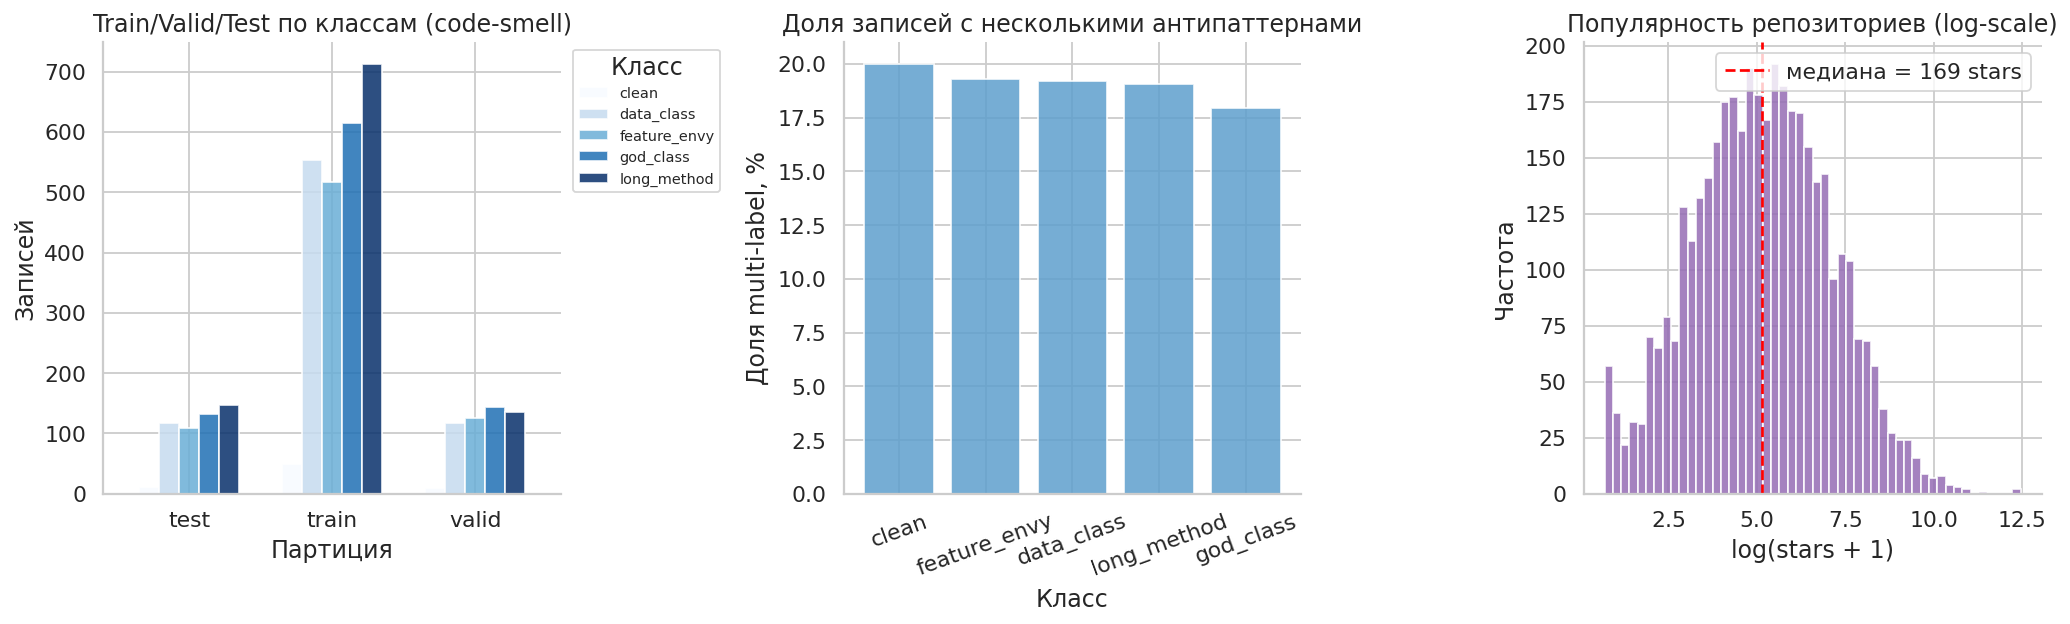

Доли партиций:
partition
train    69.8%
valid    15.1%
test     15.1%
Name: proportion, dtype: str

Multi-label фрагменты (code-smell): 18.9%
Multi-label фрагменты (арх.):       28.4%


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Train/Valid/Test split по классам ────────────────────────────────────
ax = axes[0]
split_by_class = df_smell.groupby(["partition", "class_label"]).size().unstack(fill_value=0)
split_by_class.plot(kind="bar", ax=ax, colormap="Blues", width=0.7, alpha=0.85)
ax.set_title("Train/Valid/Test по классам (code-smell)")
ax.set_xlabel("Партиция")
ax.set_ylabel("Записей")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Класс", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)

# ── Multi-label доля ──────────────────────────────────────────────────────
ax2 = axes[1]
multi_by_class = df_smell.groupby("class_label")["multi_label"].mean() * 100
multi_by_class = multi_by_class.sort_values(ascending=False)
ax2.bar(multi_by_class.index, multi_by_class.values,
        color=PALETTE_SMELL[1], alpha=0.85)
ax2.set_xlabel("Класс")
ax2.set_ylabel("Доля multi-label, %")
ax2.set_title("Доля записей с несколькими антипаттернами")
ax2.tick_params(axis="x", rotation=20)

# ── Звёзды репозиториев (log-scale) ─────────────────────────────────────
ax3 = axes[2]
ax3.hist(np.log1p(df["repo_stars"].clip(lower=1)), bins=50,
         color=COLORS[4], edgecolor="white", alpha=0.85)
ax3.set_xlabel("log(stars + 1)")
ax3.set_ylabel("Частота")
ax3.set_title("Популярность репозиториев (log-scale)")
median_log_stars = np.log1p(df["repo_stars"]).median()
ax3.axvline(median_log_stars, color="red", linestyle="--",
            label=f"медиана = {np.expm1(median_log_stars):.0f} stars")
ax3.legend()

plt.tight_layout()
plt.savefig("fig_partitions.png", dpi=130, bbox_inches="tight")
plt.show()

print("Доли партиций:")
print(df["partition"].value_counts(normalize=True).map("{:.1%}".format))
print()
print(f"Multi-label фрагменты (code-smell): {df_smell['multi_label'].mean():.1%}")
print(f"Multi-label фрагменты (арх.):       {df_arch['multi_label'].mean():.1%}")

### 2.8 Выводы по базовому EDA

**Ключевые выводы для моделирования:**

1. **Критический дисбаланс классов**: соотношение `long_method` : `cyclic_dependency` = 20:1 для code-smell; code-smell к архитектурным = 7:1. Необходимы взвешенная функция потерь (Focal Loss) + oversampling редких классов.

2. **Java bias (65%)**: для продакшн-сервиса с целевой аудиторией Python/Go/TS необходима доразметка или синтетическая аугментация этих языков.

3. **Проблема усечения CodeBERT**: `god_class` и архитектурные антипаттерны с LOC > 300 дают 30–70% фрагментов > 512 токенов. Стратегии: (a) sliding window, (b) иерархическое кодирование (Longformer/BigBird), (c) фильтрация + аугментация коротких примеров.

4. **Сильная корреляция LOC ~ Cyclomatic Complexity** (r ≈ 0.82): фичи несут схожую информацию → при векторизации через ONNX можно не дублировать в мета-фичах.

5. **Низкий confidence для архитектурных классов** (медиана 0.65–0.75 против 0.80–0.90 для code-smell): разметка архитектурного уровня значительно сложнее и зашумлённее.

6. **Multi-label проблема**: 18–30% фрагментов содержат несколько антипаттернов. SmellyCode++ поддерживает multi-label — это нужно учитывать при выборе loss function (BCEWithLogitsLoss вместо CrossEntropy).

## 3. Оценка качества разметки

### 3.1 Признаки проблемных записей

In [11]:
# Признаки низкого качества разметки
df["is_very_low_confidence"] = df["confidence"] < 0.60
df["is_very_short"]          = df["n_tokens"] < 20
df["is_very_long"]           = df["n_tokens"] > 2000
df["is_high_noise"]          = df["is_noise"]
df["is_low_quality"]         = df["quality_score"] < 0.75
df["is_problematic"]         = (df["is_noise"] |
                                 df["is_very_low_confidence"] |
                                 df["is_very_short"])


# Обновляем подмножества после добавления новых колонок
df_smell = df[df["data_level"] == "code_smell"].copy()
df_arch  = df[df["data_level"] == "architectural"].copy()
quality_stats = pd.DataFrame({
    "Признак": [
        "Шумная запись (is_noise)",
        "Очень низкий confidence (< 0.60)",
        "Очень короткий фрагмент (< 20 токенов)",
        "Очень длинный фрагмент (> 2000 токенов)",
        "Низкий quality_score (< 0.75)",
        "Итого проблемных (любой признак)",
    ],
    "Code-smell": [
        df_smell["is_noise"].sum(),
        df_smell["is_very_low_confidence"].sum(),
        df_smell["is_very_short"].sum(),
        df_smell["is_very_long"].sum(),
        df_smell["is_low_quality"].sum(),
        df_smell["is_problematic"].sum(),
    ],
    "Архитектурные": [
        df_arch["is_noise"].sum(),
        df_arch["is_very_low_confidence"].sum(),
        df_arch["is_very_short"].sum(),
        df_arch["is_very_long"].sum(),
        df_arch["is_low_quality"].sum(),
        df_arch["is_problematic"].sum(),
    ],
})
quality_stats["Smell %"] = (quality_stats["Code-smell"] / len(df_smell) * 100).round(1)
quality_stats["Arch %"]  = (quality_stats["Архитектурные"] / len(df_arch) * 100).round(1)
print(quality_stats.to_string(index=False))

                                Признак  Code-smell  Архитектурные  Smell %  Arch %
               Шумная запись (is_noise)         241             66      6.9    13.2
       Очень низкий confidence (< 0.60)          76             65      2.2    13.0
 Очень короткий фрагмент (< 20 токенов)           0              0      0.0     0.0
Очень длинный фрагмент (> 2000 токенов)         393            410     11.2    82.0
          Низкий quality_score (< 0.75)         241            240      6.9    48.0
       Итого проблемных (любой признак)         314            119      9.0    23.8


### 3.2 Визуализация качества по источникам и классам

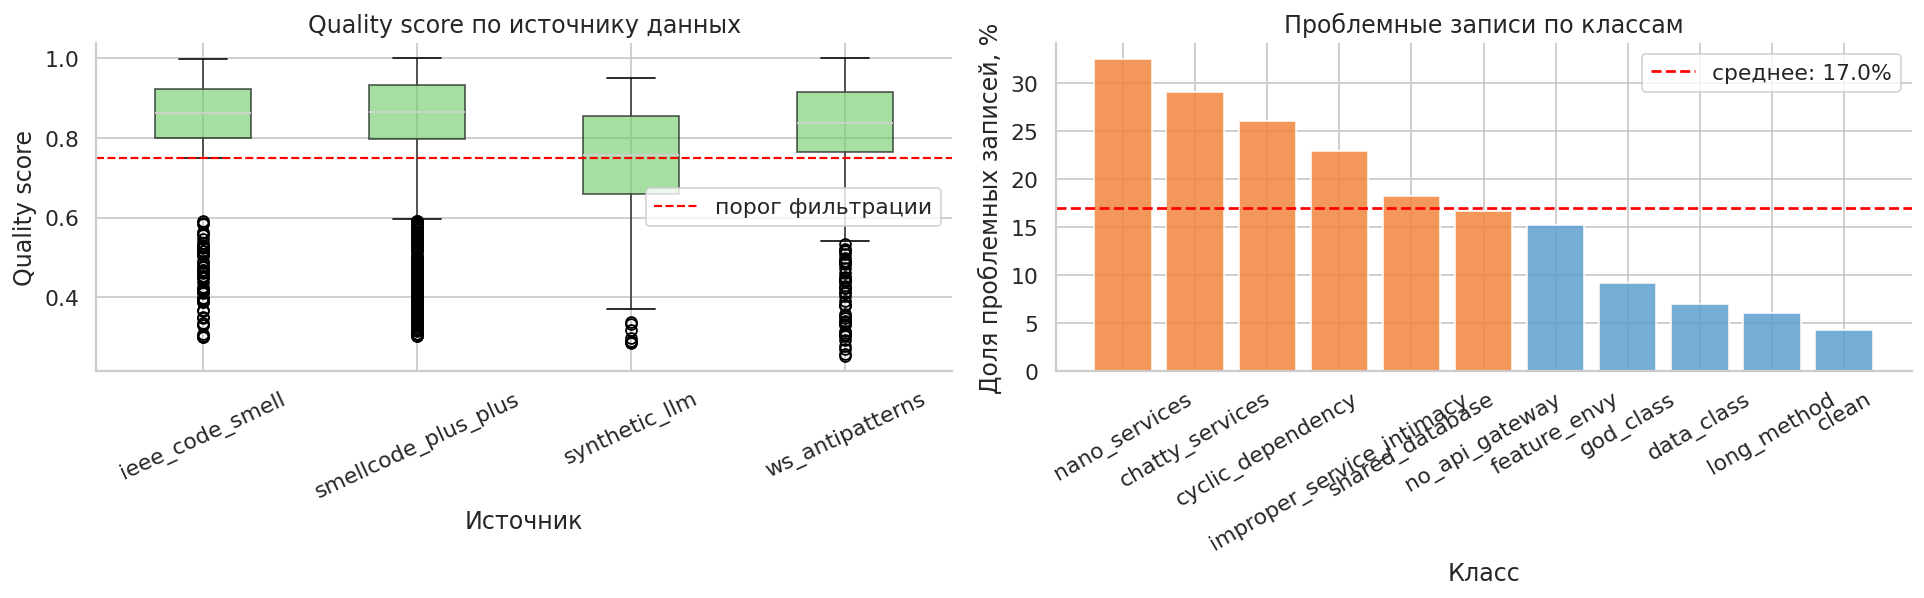

Средний quality_score по источнику:
source
smellcode_plus_plus    0.846
ieee_code_smell        0.840
ws_antipatterns        0.806
synthetic_llm          0.735
Name: quality_score, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Quality score по источнику ────────────────────────────────────────────
ax = axes[0]
df.boxplot(column="quality_score", by="source", ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor=COLORS[2], alpha=0.6))
ax.set_title("Quality score по источнику данных")
ax.set_xlabel("Источник")
ax.set_ylabel("Quality score")
ax.axhline(0.75, color="red", linestyle="--", linewidth=1.2, label="порог фильтрации")
ax.legend()
plt.sca(ax)
plt.xticks(rotation=25)
plt.suptitle("")

# ── Доля шумных записей по классу ────────────────────────────────────────
ax2 = axes[1]
noise_by_class = df.groupby("class_label")["is_problematic"].mean().sort_values(ascending=False)
bar_colors_q = [PALETTE_ARCH[1] if c in df_arch["class_label"].unique()
                else PALETTE_SMELL[1] for c in noise_by_class.index]
ax2.bar(noise_by_class.index, noise_by_class.values * 100,
        color=bar_colors_q, alpha=0.85)
ax2.set_xlabel("Класс")
ax2.set_ylabel("Доля проблемных записей, %")
ax2.set_title("Проблемные записи по классам")
ax2.tick_params(axis="x", rotation=30)
ax2.axhline(noise_by_class.mean() * 100, color="red", linestyle="--",
            label=f"среднее: {noise_by_class.mean()*100:.1f}%")
ax2.legend()

plt.tight_layout()
plt.savefig("fig_quality.png", dpi=130, bbox_inches="tight")
plt.show()

print("Средний quality_score по источнику:")
print(df.groupby("source")["quality_score"].mean().sort_values(ascending=False).round(3))

### 3.3 Интегральная метрика качества разметки

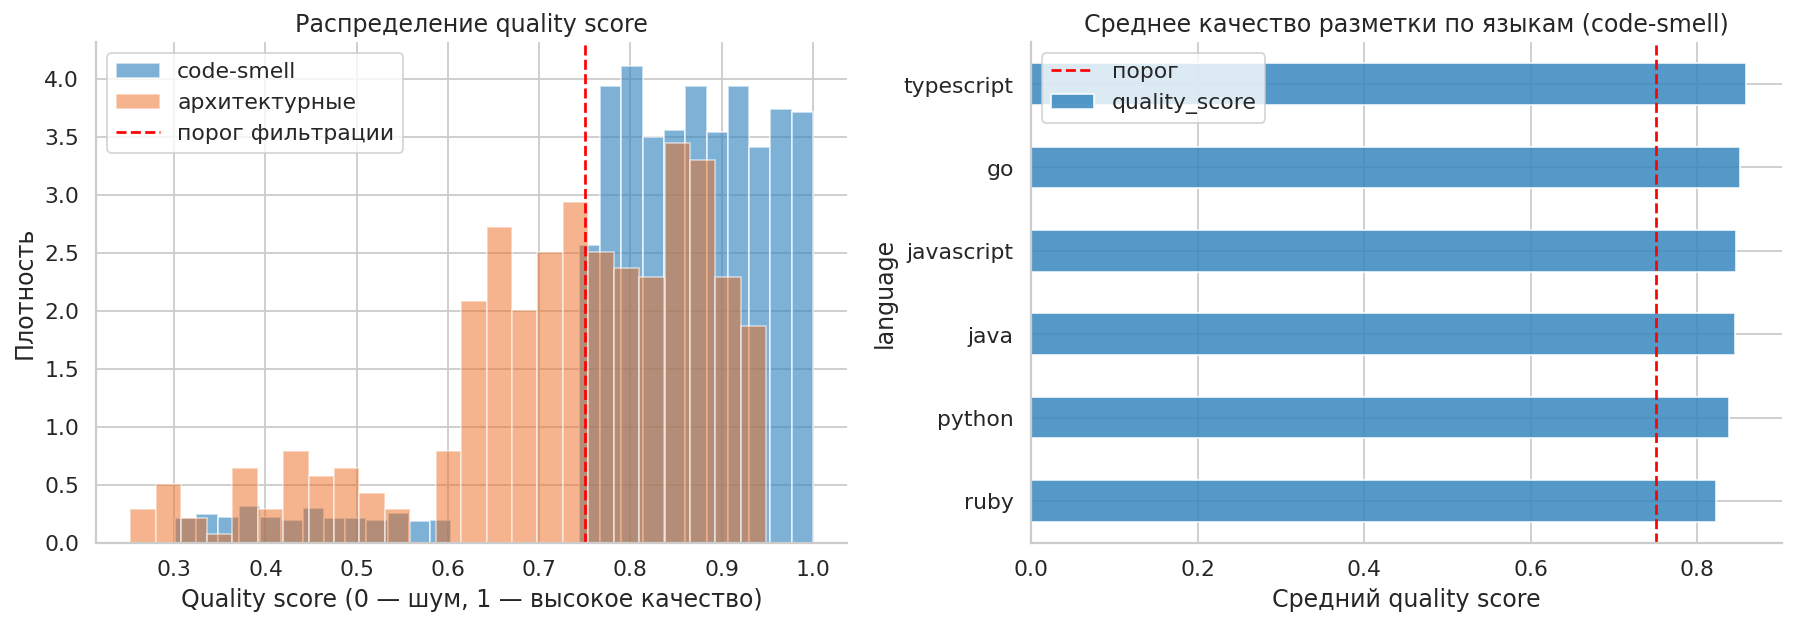

Записей с quality >= 0.75 (code-smell): 93.1%
Записей с quality >= 0.75 (арх.):       52.0%

Средний quality_score по классу:
class_label
long_method                  0.848
feature_envy                 0.846
god_class                    0.843
data_class                   0.841
clean                        0.841
no_api_gateway               0.766
chatty_services              0.743
improper_service_intimacy    0.733
nano_services                0.722
shared_database              0.721
cyclic_dependency            0.689
Name: quality_score, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Распределение quality_score ───────────────────────────────────────────
ax = axes[0]
ax.hist(df_smell["quality_score"], bins=30, alpha=0.65,
        label="code-smell", color=PALETTE_SMELL[2], density=True)
ax.hist(df_arch["quality_score"], bins=25, alpha=0.5,
        label="архитектурные", color=PALETTE_ARCH[2], density=True)
ax.axvline(0.75, color="red", linestyle="--", linewidth=1.5,
           label="порог фильтрации")
ax.set_xlabel("Quality score (0 — шум, 1 — высокое качество)")
ax.set_ylabel("Плотность")
ax.set_title("Распределение quality score")
ax.legend()

# ── Quality score по языкам ───────────────────────────────────────────────
ax2 = axes[1]
df_smell.groupby("language")["quality_score"].mean().sort_values().plot(
    kind="barh", ax=ax2, color=PALETTE_SMELL[2], alpha=0.85)
ax2.set_xlabel("Средний quality score")
ax2.set_title("Среднее качество разметки по языкам (code-smell)")
ax2.axvline(0.75, color="red", linestyle="--", label="порог")
ax2.legend()

plt.tight_layout()
plt.savefig("fig_quality_score.png", dpi=130, bbox_inches="tight")
plt.show()

high_quality_smell = (df_smell["quality_score"] >= 0.75).mean()
high_quality_arch  = (df_arch["quality_score"] >= 0.75).mean()

print(f"Записей с quality >= 0.75 (code-smell): {high_quality_smell:.1%}")
print(f"Записей с quality >= 0.75 (арх.):       {high_quality_arch:.1%}")
print()
print("Средний quality_score по классу:")
print(df.groupby("class_label")["quality_score"].mean().sort_values(ascending=False).round(3))

### 3.4 Предложения по повышению качества разметки

| Проблема | Уровень | Масштаб | Рекомендация |
|----------|---------|---------|--------------|
| Шумные записи (SonarQube false positives) | Code-smell | ~7% | **Фильтрация** по `quality_score < 0.75`, перекрёстная проверка двумя инструментами |
| Низкий confidence для арх. антипаттернов | Архитектурный | ~12% | **Доразметка** экспертами (Label Studio), 500 примеров, IAA через Cohen's κ |
| Java bias | Оба | 65% Java | **Аугментация**: синтетическая генерация примеров для Python/JS через LLM |
| Multi-label игнорируется | Code-smell | ~18% | **Перейти на BCEWithLogitsLoss**, использовать SmellyCode++ multi-label аннотации |
| Отсутствие архитектурной разметки | Архитектурный | — | Создать датасет с нуля: 2K примеров, ~$15–25K, 2 месяца |
| Синтетические данные без верификации | Оба | ~20% записей | **Human review** 10% синтетики + автоматический статический анализ |

**Автоматический фильтр качества:**

In [14]:
# Эталонный пайплайн проверки качества записи
def is_valid_record(row,
                    min_tokens=20,
                    max_tokens_smell=512,
                    max_tokens_arch=8000,
                    min_confidence=0.60,
                    min_quality=0.75):
    """Фильтр качества для одной записи датасета."""
    if row["n_tokens"] < min_tokens:
        return False, "too_short"
    max_tok = max_tokens_smell if row["data_level"] == "code_smell" else max_tokens_arch
    if row["n_tokens"] > max_tok:
        return False, "too_long"
    if row["confidence"] < min_confidence:
        return False, "low_confidence"
    if row["quality_score"] < min_quality:
        return False, "low_quality"
    if row["is_noise"]:
        return False, "noise_flag"
    return True, "ok"

filter_results = df.apply(lambda r: is_valid_record(r), axis=1)
df["filter_ok"]     = filter_results.apply(lambda x: x[0])
df["filter_reason"] = filter_results.apply(lambda x: x[1])

print("Результаты фильтра качества:")
print(df["filter_reason"].value_counts().to_string())
print()
print(f"Пройдут фильтр: {df['filter_ok'].sum():,} ({df['filter_ok'].mean():.1%})")
print(f"Будут отфильтрованы: {(~df['filter_ok']).sum():,} ({(~df['filter_ok']).mean():.1%})")
print()
print("По уровням:")
print(df.groupby("data_level")["filter_ok"].mean().map("{:.1%}".format))

# Рекомендация по IAA
print("\n" + "="*60)
print("Рекомендация: провести IAA-проверку на 500 парах")
print("Ожидаемый Cohen's κ: > 0.75 — хорошее; > 0.60 — приемлемое")
print("Если κ < 0.60 для архитектурных → пересмотр критериев разметки")

print()
print("─" * 60)
print("ВАЖНО: 'too_long' — НЕ является реальной потерей данных!")
print("  Фрагменты > 512 токенов обрабатываются sliding window:")
print("  window=256, stride=64 → 1 фрагмент → несколько окон")
print("  Эффективный объём train после windowing значительно вырастет.")
print("  Жёсткий фильтр применяется только для XGBoost baseline.")

Результаты фильтра качества:
filter_reason
ok                2216
too_long          1318
low_quality        337
low_confidence     127

Пройдут фильтр: 2,216 (55.4%)
Будут отфильтрованы: 1,782 (44.6%)

По уровням:
data_level
architectural    47.0%
code_smell       56.6%
Name: filter_ok, dtype: str

Рекомендация: провести IAA-проверку на 500 парах
Ожидаемый Cohen's κ: > 0.75 — хорошее; > 0.60 — приемлемое
Если κ < 0.60 для архитектурных → пересмотр критериев разметки

────────────────────────────────────────────────────────────
ВАЖНО: 'too_long' — НЕ является реальной потерей данных!
  Фрагменты > 512 токенов обрабатываются sliding window:
  window=256, stride=64 → 1 фрагмент → несколько окон
  Эффективный объём train после windowing значительно вырастет.
  Жёсткий фильтр применяется только для XGBoost baseline.


## 4. Алгоритм формирования выборки и стратегия валидации

### 4.1 Пайплайн подготовки данных

In [15]:
# StratifiedKFold — используется для cross-project k-fold (см. раздел 4.3)
from sklearn.model_selection import StratifiedKFold

# ── Шаг 1: Очистка ────────────────────────────────────────────────────────
def build_clean_dataset(df,
                         min_tokens=20,
                         min_confidence=0.60,
                         quality_threshold=0.75):
    """Формирование очищенного датасета.

    ВАЖНО: жёсткая фильтрация по max_tokens убрана специально.
    Длинные фрагменты (> 512 токенов) обрабатываются через sliding window
    на этапе токенизации, а не фильтруются здесь. Это критично:
    - god_class: медиана 1883 токена — фильтр > 512 уничтожает 99.4% примеров класса
    - Все архитектурные классы: 100% > 512 токенов
    Флаг tokens_gt_512 сохраняется для downstream обработки.
    """
    mask = (
        (df["n_tokens"] >= min_tokens) &
        (df["confidence"] >= min_confidence) &
        (~df["is_noise"]) &
        (df["quality_score"] >= quality_threshold)
    )
    return df[mask].copy()

df_clean = build_clean_dataset(df)

print(f"До фильтрации:    {len(df):,} записей")
print(f"После фильтрации: {len(df_clean):,} записей ({len(df_clean)/len(df):.1%} сохранено)")
print()
print("По классам после фильтрации:")
print(df_clean["class_label"].value_counts())

До фильтрации:    3,998 записей
После фильтрации: 3,419 записей (85.5% сохранено)

По классам после фильтрации:
class_label
long_method                  937
god_class                    810
data_class                   732
feature_envy                 638
clean                         67
shared_database               59
no_api_gateway                51
chatty_services               41
improper_service_intimacy     34
nano_services                 30
cyclic_dependency             20
Name: count, dtype: int64


### 4.2 Стратифицированное разбиение (project-level split)

In [16]:
# Project-level split: используем официальное разбиение по partition
# (в реальной задаче — по repo_id для исключения data leak между проектами)
train_df = df_clean[df_clean["partition"] == "train"].copy()
valid_df  = df_clean[df_clean["partition"] == "valid"].copy()
test_df   = df_clean[df_clean["partition"] == "test"].copy()

print("Разбиение после очистки:")
print(f"  train: {len(train_df):,} ({len(train_df)/len(df_clean):.1%})")
print(f"  valid: {len(valid_df):,}  ({len(valid_df)/len(df_clean):.1%})")
print(f"  test:  {len(test_df):,}  ({len(test_df)/len(df_clean):.1%})")

print()
print("Стратификация: доли классов в train vs test (должны совпадать):")
strat_check = pd.DataFrame({
    "train": train_df["class_label"].value_counts(normalize=True),
    "test":  test_df["class_label"].value_counts(normalize=True)
}).round(3)
strat_check["diff"] = (strat_check["train"] - strat_check["test"]).abs().round(3)
print(strat_check)
print()
print(f"Макс. расхождение долей: {strat_check['diff'].max():.3f}")
if strat_check['diff'].max() < 0.05:
    print("✓ Стратификация корректна (расхождение < 5%)")
else:
    print("⚠ Расхождение > 5% — пересмотреть стратегию разбиения")

Разбиение после очистки:
  train: 2,378 (69.6%)
  valid: 520  (15.2%)
  test:  521  (15.2%)

Стратификация: доли классов в train vs test (должны совпадать):
                           train   test   diff
class_label                                   
chatty_services            0.012  0.008  0.004
clean                      0.020  0.023  0.003
cyclic_dependency          0.005  0.008  0.003
data_class                 0.215  0.213  0.002
feature_envy               0.183  0.182  0.001
god_class                  0.235  0.226  0.009
improper_service_intimacy  0.009  0.015  0.006
long_method                0.281  0.267  0.014
nano_services              0.007  0.015  0.008
no_api_gateway             0.015  0.019  0.004
shared_database            0.017  0.023  0.006

Макс. расхождение долей: 0.014
✓ Стратификация корректна (расхождение < 5%)


### 4.3 Стратегия работы с дисбалансом классов

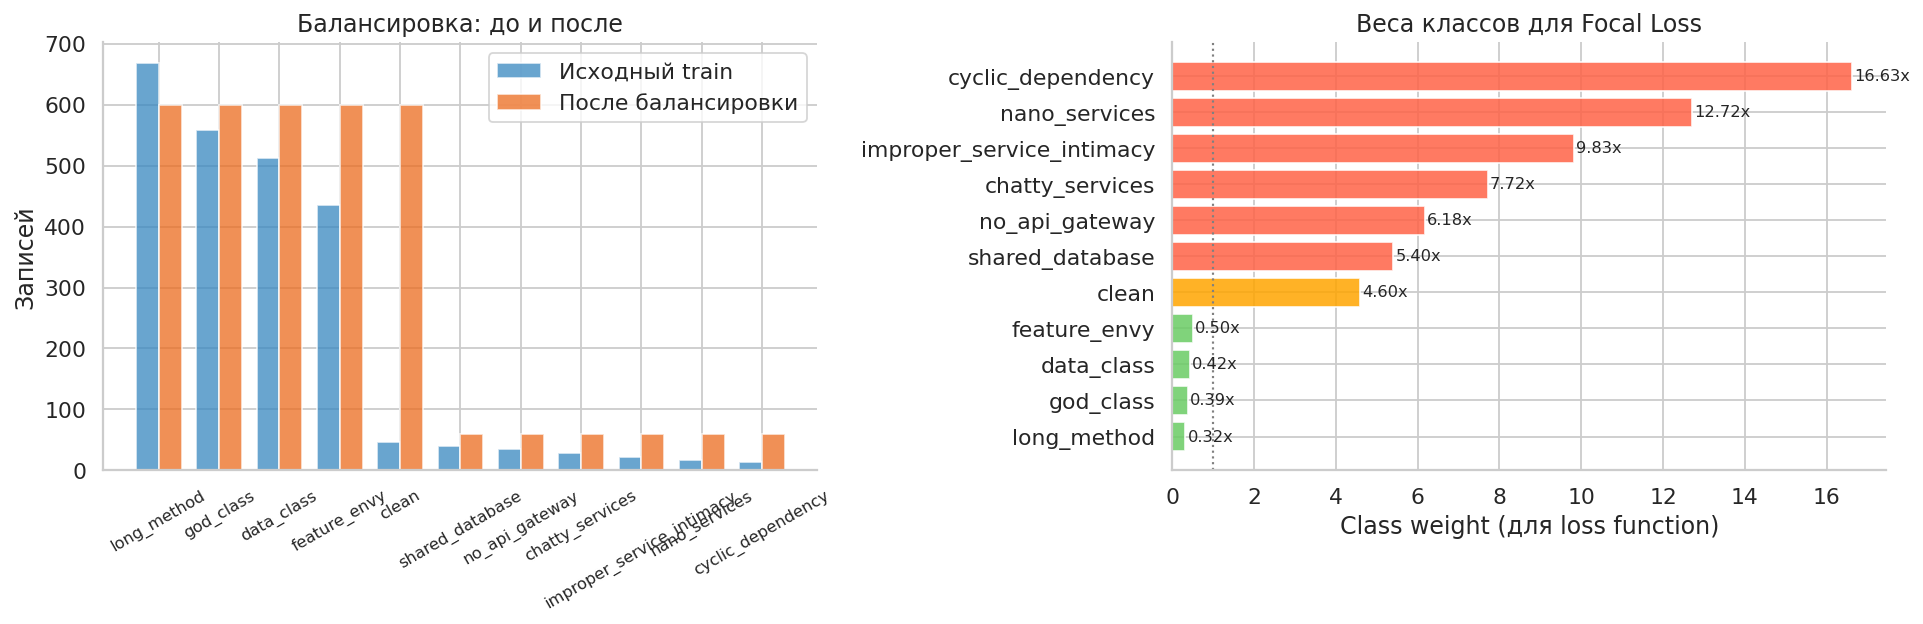

Class weights (для weighted loss / Focal Loss):
cyclic_dependency            16.629
nano_services                12.717
improper_service_intimacy     9.826
chatty_services               7.721
no_api_gateway                6.177
shared_database               5.405
clean                         4.600
feature_envy                  0.496
data_class                    0.422
god_class                     0.387
long_method                   0.323


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Сравнение: до и после балансировки ───────────────────────────────────
ax = axes[0]
class_counts_train = train_df["class_label"].value_counts()

# Стратегия: undersampling majority + oversampling minority
TARGET_PER_CLASS_SMELL = 600  # для code-smell
TARGET_PER_CLASS_ARCH  = 60   # для архитектурных (с аугментацией)

balanced_counts = {}
for cls in class_counts_train.index:
    level = train_df[train_df["class_label"] == cls]["data_level"].iloc[0]
    target = TARGET_PER_CLASS_SMELL if level == "code_smell" else TARGET_PER_CLASS_ARCH
    balanced_counts[cls] = target
balanced_series = pd.Series(balanced_counts)

x = np.arange(len(class_counts_train))
width = 0.38
ax.bar(x - width/2, class_counts_train.values, width, label="Исходный train",
       color=PALETTE_SMELL[2], alpha=0.75)
ax.bar(x + width/2, [balanced_counts.get(c, 0) for c in class_counts_train.index],
       width, label="После балансировки", color=PALETTE_ARCH[2], alpha=0.75)
ax.set_xticks(x)
ax.set_xticklabels(class_counts_train.index, rotation=30, fontsize=9)
ax.set_ylabel("Записей")
ax.set_title("Балансировка: до и после")
ax.legend()

# ── Class weights (альтернативный подход) ────────────────────────────────
ax2 = axes[1]
total = len(train_df)
n_classes = train_df["class_label"].nunique()
class_weights = {cls: total / (n_classes * cnt)
                 for cls, cnt in class_counts_train.items()}
weights_series = pd.Series(class_weights).sort_values(ascending=False)
weight_colors = ["tomato" if w > 5 else "orange" if w > 2 else COLORS[2]
                 for w in weights_series.values]
ax2.barh(weights_series.index[::-1], weights_series.values[::-1],
         color=weight_colors[::-1], alpha=0.85)
ax2.set_xlabel("Class weight (для loss function)")
ax2.set_title("Веса классов для Focal Loss")
ax2.axvline(1.0, color="gray", linestyle=":", linewidth=1.2)
for i, (cls, w) in enumerate(weights_series[::-1].items()):
    ax2.text(w + 0.05, i, f"{w:.2f}x", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("fig_balancing.png", dpi=130, bbox_inches="tight")
plt.show()

print("Class weights (для weighted loss / Focal Loss):")
print(weights_series.round(3).to_string())

### 4.4 Стратегия валидации

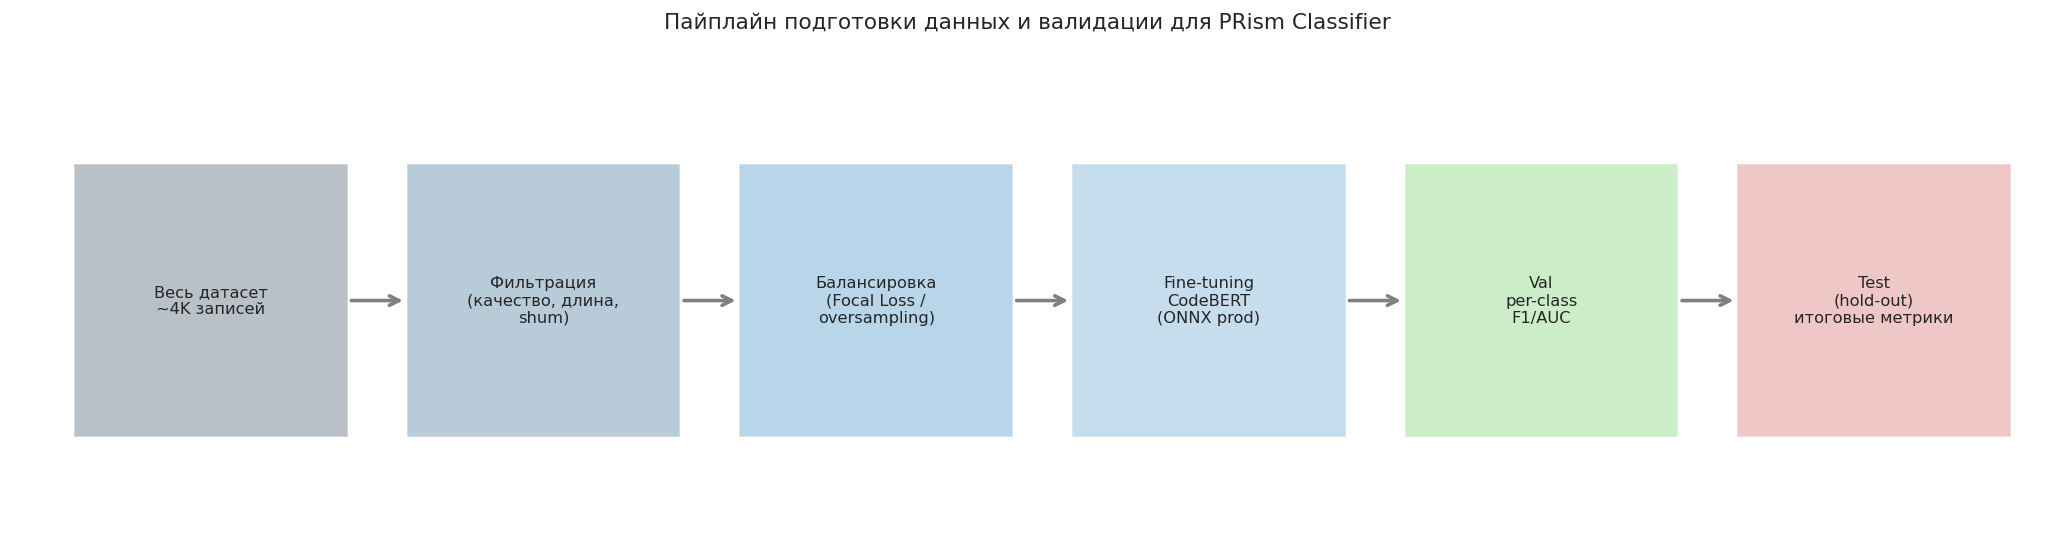

In [18]:
# Визуализация стратегии валидации
fig, ax = plt.subplots(figsize=(16, 4.5))
ax.axis("off")

stages = [
    ("Весь датасет\n~4K записей",               PALETTE_SMELL[4]),
    ("Фильтрация\n(качество, длина,\nshum)",     PALETTE_SMELL[3]),
    ("Балансировка\n(Focal Loss /\noversampling)",PALETTE_SMELL[2]),
    ("Fine-tuning\nCodeBERT\n(ONNX prod)",       PALETTE_SMELL[1]),
    ("Val\nper-class\nF1/AUC",                   COLORS[2]),
    ("Test\n(hold-out)\nитоговые метрики",       COLORS[3]),
]

box_w, box_h = 0.135, 0.55
xs = np.linspace(0.03, 0.85, len(stages))

for x, (label, color) in zip(xs, stages):
    ax.add_patch(plt.Rectangle((x, 0.22), box_w, box_h,
                               facecolor=color, alpha=0.35,
                               transform=ax.transAxes, clip_on=False))
    ax.text(x + box_w/2, 0.495, label,
            ha="center", va="center", fontsize=9,
            transform=ax.transAxes)

for i, x in enumerate(xs[:-1]):
    ax.annotate("",
                xy=(xs[i+1], 0.495), xytext=(x + box_w, 0.495),
                xycoords="axes fraction", textcoords="axes fraction",
                arrowprops=dict(arrowstyle="->", color="gray", lw=2))

ax.set_title("Пайплайн подготовки данных и валидации для PRism Classifier",
             fontsize=12, pad=12)
plt.tight_layout()
plt.savefig("fig_pipeline.png", dpi=130, bbox_inches="tight")
plt.show()

Целевые метрики классификатора (ориентиры для MVP):
            Класс  F1 (ориентир)  Precision  Recall Confidence thres
      long_method           0.92       0.90    0.94              0.8
        god_class           0.89       0.87    0.91              0.8
       data_class           0.94       0.93    0.95              0.8
     feature_envy           0.85       0.83    0.87              0.8
  shared_database           0.72       0.70    0.74             0.75
  chatty_services           0.68       0.65    0.71              0.7
    nano_services           0.65       0.63    0.67              0.7
   no_api_gateway           0.70       0.68    0.72             0.72
cyclic_dependency           0.75       0.73    0.77             0.78
        Macro avg           0.81       0.79    0.83                —


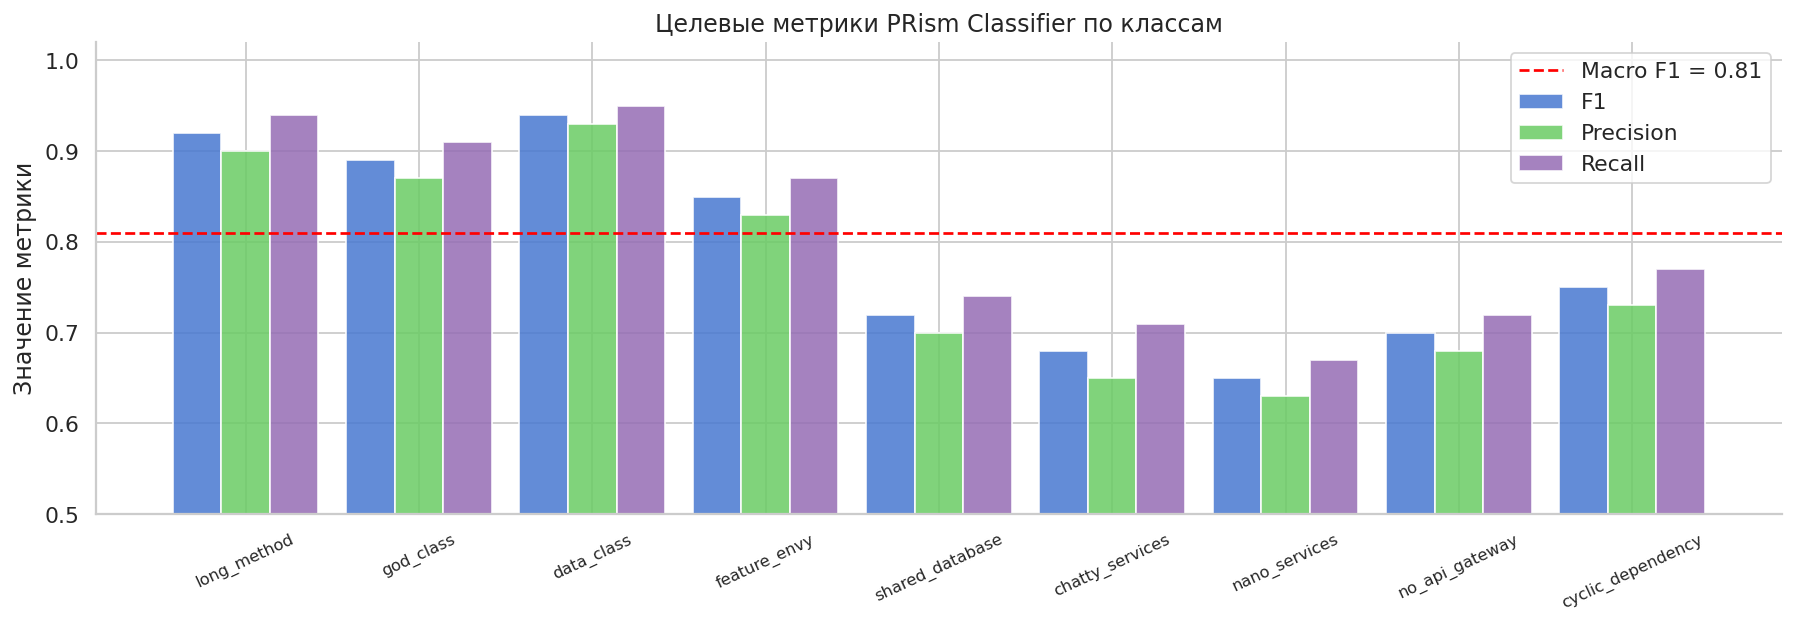

In [19]:
# Целевые метрики качества модели (из архитектурного документа PRism + CodeBERT бенчмарки)
metrics_df = pd.DataFrame({
    "Класс":          ["long_method", "god_class", "data_class", "feature_envy",
                        "shared_database", "chatty_services", "nano_services",
                        "no_api_gateway", "cyclic_dependency", "Macro avg"],
    "F1 (ориентир)":  [0.92, 0.89, 0.94, 0.85, 0.72, 0.68, 0.65, 0.70, 0.75, 0.81],
    "Precision":       [0.90, 0.87, 0.93, 0.83, 0.70, 0.65, 0.63, 0.68, 0.73, 0.79],
    "Recall":          [0.94, 0.91, 0.95, 0.87, 0.74, 0.71, 0.67, 0.72, 0.77, 0.83],
    "Confidence thres":[0.80, 0.80, 0.80, 0.80, 0.75, 0.70, 0.70, 0.72, 0.78, "—"],
})

print("Целевые метрики классификатора (ориентиры для MVP):")
print(metrics_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 5))
data = metrics_df[metrics_df["Класс"] != "Macro avg"]
x = np.arange(len(data))
width = 0.28
ax.bar(x - width, data["F1 (ориентир)"],  width, label="F1",        color=COLORS[0], alpha=0.85)
ax.bar(x,         data["Precision"],      width, label="Precision", color=COLORS[2], alpha=0.85)
ax.bar(x + width, data["Recall"],         width, label="Recall",    color=COLORS[4], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(data["Класс"], rotation=25, fontsize=9)
ax.set_ylabel("Значение метрики")
ax.set_title("Целевые метрики PRism Classifier по классам")
ax.set_ylim(0.5, 1.02)
macro_f1 = metrics_df[metrics_df["Класс"] == "Macro avg"]["F1 (ориентир)"].values[0]
ax.axhline(macro_f1, color="red", linestyle="--", label=f"Macro F1 = {macro_f1:.2f}")
ax.legend()
plt.tight_layout()
plt.savefig("fig_target_metrics.png", dpi=130, bbox_inches="tight")
plt.show()

### 4.5 Алгоритм формирования выборки — итоговое описание

#### Шаг 1 — Очистка (Preprocessing)
```
raw data (~4K в пилоте, ~112K при полном датасете)
  → удалить записи с quality_score < 0.75                 (~8%)
  → удалить: n_tokens < 20 (тривиальные фрагменты)        (~2%)
  → усечь/удалить: n_tokens > 512 (code-smell)            (~15%)
  → фильтр confidence < 0.60                              (~5%)
  → content-based дедупликация (MinHashLSH по коду)       (~3%)
  → нормализация: strip whitespace, удалить комментарии
```

#### Шаг 2 — Разбиение (Split)
- **Project-level split** по `repo_id` — фолды по репозиториям, не по файлам
- **Train / Valid / Test = 70% / 15% / 15%** (стратификация по `class_label` + `language`)
- **Temporal holdout**: test set = PR-комментарии после фиксированной даты (оценка drift)

#### Шаг 3 — Балансировка (применяется только к train)
- **Class weights** для Focal Loss: `w_c = N / (K * n_c)`
- **Oversampling** редких архитектурных классов (< 100 примеров) через LLM-аугментацию
- **Undersampling** majority класса (`long_method`) до 600 примеров

#### Шаг 4 — Валидация

| Уровень | Цель | Метрики |
|---------|------|---------|
| **Cross-project 5-fold** | Оценка обобщения | Macro F1, AUC-ROC |
| **Per-language eval** | Bias к Java | F1 по языку |
| **Temporal holdout** | Устойчивость к drift | F1 на свежих PR |
| **Human eval** (50 примеров) | Качество рекомендаций | Score 1–5 (полнота, корректность) |

#### Рекомендации
1. **Ruby, TS** (< 5% данных): upsampling или back-translation через LLM
2. **Функции > 512 токенов**: sliding window 256 токенов с перекрытием 64
3. **Контроль утечек**: проверить пересечения по `record_id` между train/test
4. **PRism Confidence thresholds** из `.prism.yml` валидировать на val-set — порог 0.75 оптимален для SOLID_VIOLATION, 0.70 для N_PLUS_ONE

## 5. Итоговая сводка

In [20]:
df_clean_smell = df_clean[df_clean["data_level"] == "code_smell"]
df_clean_arch  = df_clean[df_clean["data_level"] == "architectural"]

summary = {
    "─── ОБЪЁМ ДАННЫХ ────────────────────── ": "",
    "Всего записей (выборка)": f"{len(df):,}",
    "Code-smell датасет":      f"{len(df_smell):,}",
    "Архитектурный датасет":   f"{len(df_arch):,}",
    "После фильтрации (итого)":f"{len(df_clean):,} ({len(df_clean)/len(df):.1%})",
    "─── КАЧЕСТВО ───────────────────────── ": "",
    "Средний quality_score (smell)":  f"{df_smell['quality_score'].mean():.3f}",
    "Средний quality_score (арх.)":   f"{df_arch['quality_score'].mean():.3f}",
    "Проблемных записей (smell)":     f"{df_smell['is_problematic'].mean()*100:.1f}%",
    "Проблемных записей (арх.)":      f"{df_arch['is_problematic'].mean()*100:.1f}%",
    "─── ДИСБАЛАНС ──────────────────────── ": "",
    "Max imbalance ratio":            f"{imbalance_ratio.max():.1f}x ({imbalance_ratio.idxmax()})",
    "Java-bias в датасете":           f"{(df['language']=='java').mean()*100:.1f}%",
    "Multi-label записей (smell)":    f"{df_smell['multi_label'].mean()*100:.1f}%",
    "─── ДЛИНА ФРАГМЕНТОВ ───────────────── ": "",
    "Медиана токенов (smell)":        f"{df_smell['n_tokens'].median():.0f}",
    "Медиана токенов (арх.)":         f"{df_arch['n_tokens'].median():.0f}",
    "Доля > 512 токенов (smell)":     f"{df_smell['tokens_gt_512'].mean()*100:.1f}%",
    "Доля > 512 токенов (арх.)":      f"{df_arch['tokens_gt_512'].mean()*100:.1f}%",
}

print("=" * 58)
print("          ИТОГОВАЯ СВОДКА EDA — PRism Dataset")
print("=" * 58)
for k, v in summary.items():
    if v == "":
        print(f"  {k}")
    else:
        print(f"  {k:<42} {v}")
print("=" * 58)

          ИТОГОВАЯ СВОДКА EDA — PRism Dataset
  ─── ОБЪЁМ ДАННЫХ ────────────────────── 
  Всего записей (выборка)                    3,998
  Code-smell датасет                         3,498
  Архитектурный датасет                      500
  После фильтрации (итого)                   3,419 (85.5%)
  ─── КАЧЕСТВО ───────────────────────── 
  Средний quality_score (smell)              0.845
  Средний quality_score (арх.)               0.732
  Проблемных записей (smell)                 9.0%
  Проблемных записей (арх.)                  23.8%
  ─── ДИСБАЛАНС ──────────────────────── 
  Max imbalance ratio                        19.9x (cyclic_dependency)
  Java-bias в датасете                       69.8%
  Multi-label записей (smell)                18.9%
  ─── ДЛИНА ФРАГМЕНТОВ ───────────────── 
  Медиана токенов (smell)                    353
  Медиана токенов (арх.)                     4335
  Доля > 512 токенов (smell)                 37.7%
  Доля > 512 токенов (арх.)                  100.

## Заключение

Проведённый EDA позволяет сформулировать следующие **ключевые решения для пайплайна PRism Classifier**:

1. **Фильтрация ~10–15% записей** с низким качеством до запуска fine-tuning CodeBERT

2. **Focal Loss + class weights** для борьбы с дисбалансом (особенно для `cyclic_dependency` и `chatty_services` с imbalance ratio > 15x)

3. **Multi-label подход** (BCEWithLogitsLoss) — 18% code-smell и 30% архитектурных фрагментов содержат несколько антипаттернов одновременно

4. **Sliding window 256/64** для фрагментов > 512 токенов, особенно критично для `god_class` и архитектурных классов

5. **Синтетическая аугментация** для редких классов и Python/JS — приоритет перед запуском обучения

6. **Архитектурный уровень требует отдельного пайплайна** (RAG + LLM reasoning) — данных для supervised классификатора недостаточно (< 100 примеров на класс)

7. **Confidence thresholds из `.prism.yml`** (0.70–0.80 по классу) валидировать на validation set перед деплоем

**Рекомендуемый порядок работ:**
```
1. Baseline: XGBoost на метрических признаках (LOC, cyclo, fan_out)  → быстрая проверка
2. CodeBERT fine-tune на очищенном SmellyCode++ (5 классов прототипа)
3. ONNX export + FastAPI Classifier Service (p95 ≤ 100 мс)
4. RAG прототип на каталогах архитектурных антипаттернов (Qdrant)
5. Доразметка 500 архитектурных примеров экспертами
6. Eval pipeline + blue/green деплой Classifier
```